# Notebook for Celltyping (InsituType) of CosMX RNA Data

# TODO
- clean to test objects

## Instructions

- Make sure to run the QC pipeline first and specify the seurat object as filename in the data loading section
- Helper functions are defined in helper_functions.R (imported with other imports)
- Refining clusters requires analysis of the initial results (for guidance see: https://github.com/Nanostring-Biostats/InSituType/blob/main/FAQs.md)

## Imports

In [1]:
# Load Packages
library("Seurat")
library("dplyr")
library(ggplot2)
library(gridExtra)
library(patchwork)
library(data.table)
library(Matrix)
library(harmony)
library(ggrepel)
library(pals)
library(RColorBrewer)
library(ggrastr)
library(cluster)
library(ggrepel)
library(gtools)
library(InSituType)
library(HieraType)
library(ComplexHeatmap)
library(scPearsonPCA)
library(tibble)
library(presto)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Loading required package: Rcpp

Loading required package: grid

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.


In [31]:
# Load helper functions
source("helper_functions.R")

## Data Loading

In [3]:
# Define directories
file_path <- "../outputs/TMA18/seurat_objects/annotated_object_TMA18_louvain_final_hieratype_predictors.RDS" 
out_dir <- "../outputs" # Base output folder
# study_name <- "Test"
study_name <- "TMA18_CT_Explore"
out_dir_seu <- file.path(out_dir, study_name, "seurat_objects")
full_out_dir <- file.path(out_dir, study_name, "CT") # Output folder for this study
dir.create(full_out_dir, showWarnings = FALSE, recursive = TRUE)
dir.create(out_dir_seu, showWarnings = FALSE, recursive = TRUE)

# Load Reference for (semi) supervised clustering
reference_path <- "../inputs/InsituType_reference/BreastCancer_6k.profiles.csv"

In [4]:
seu <- readRDS(file_path)

In [5]:
seu

An object of class Seurat 
6518 features across 189704 samples within 3 assays 
Active assay: RNA (6175 features, 3000 variable features)
 2 layers present: counts, data
 2 other assays present: falsecode, negprobes
 2 dimensional reductions calculated: scpearson_pca_nobatch, scpearson_umap_nobatch

## Setting Parameters

In [6]:
method <- "semisup"
cohorting <- TRUE
subset <- FALSE
run_umap <- TRUE

# other definitions
region_col <- "region"
ASSAY_NAME <- "RNA"
condition_col <- "condition"

In [7]:
# Set RNA as Default Assay
DefaultAssay(seu) <- ASSAY_NAME

## Applying subsetting

In [13]:
# # Testing Code
# set.seed(123) # for reproducibility
# if (ncol(seu) > 20000) {
#     sampled_cells <- sample(colnames(seu), 20000)
#     seu <- seu[, sampled_cells]
# }


In [8]:
if (subset) {

    # Filter for Tumor Cores only
    seu <- subset(seu, subset = condition %in% c("T"))

    # Filter for Tumor Cores only
    seu <- subset(seu, subset = location == "F7")

}

# Drop unused levels
seu@meta.data[[region_col]] <- droplevels(seu@meta.data[[region_col]])

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


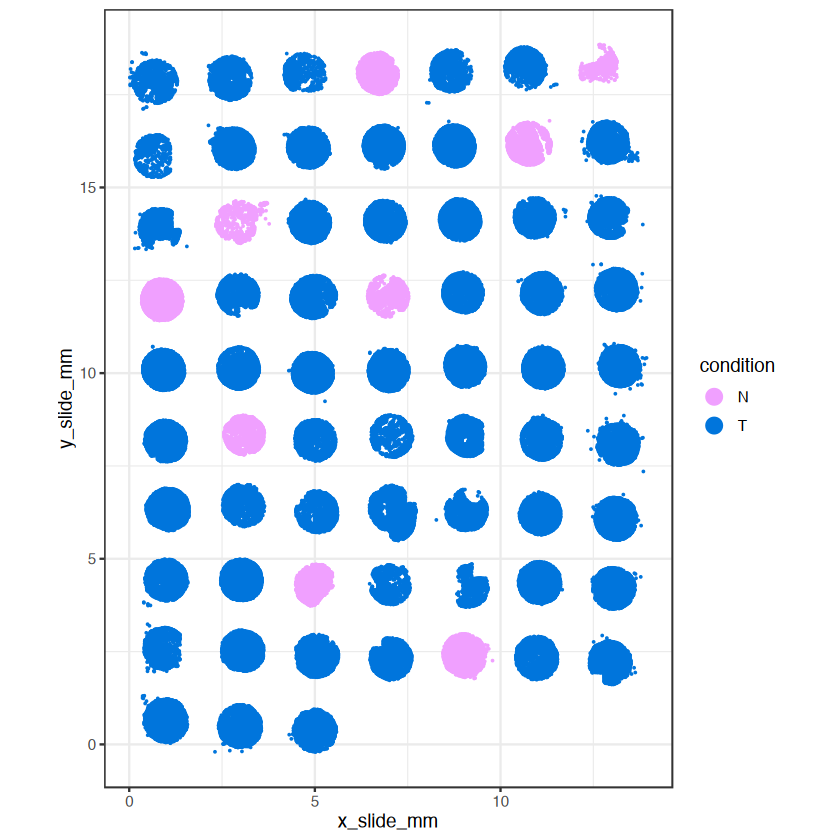

In [9]:
# Visualize the data
xyplot(condition_col, metadata = seu@meta.data, ptsize = 0.01) + coord_fixed()

In [10]:
colnames(seu@meta.data)

[1] "fov"                                                                                                          
  [2] "Area"                                                                                                         
  [3] "AspectRatio"                                                                                                  
  [4] "x_FOV_px"                                                                                                     
  [5] "y_FOV_px"                                                                                                     
  [6] "Width"                                                                                                        
  [7] "Height"                                                                                                       
  [8] "Mean.PanCK"                                                                                                   
  [9] "Max.PanCK"                                                                                                    
 [10] "Mean.G"                                                                                                       
 [11] "Max.G"                                                                                                        
 [12] "Mean.Membrane"                                                                                                
 [13] "Max.Membrane"                                                                                                 
 [14] "Mean.CD45"                                                                                                    
 [15] "Max.CD45"                                                                                                     
 [16] "Mean.DAPI"                                                                                                    
 [17] "Max.DAPI"                                                                                                     
 [18] "SplitRatioToLocal"                                                                                            
 [19] "NucArea"                                                                                                      
 [20] "NucAspectRatio"                                                                                               
 [21] "Circularity"                                                                                                  
 [22] "Eccentricity"                                                                                                 
 [23] "Perimeter"                                                                                                    
 [24] "Solidity"                                                                                                     
 [25] "cell_id"                                                                                                      
 [26] "assay_type"                                                                                                   
 [27] "version"                                                                                                      
 [28] "Run_Tissue_name"                                                                                              
 [29] "Panel"                                                                                                        
 [30] "cellSegmentationSetId"                                                                                        
 [31] "cellSegmentationSetName"                                                                                      
 [32] "slide_ID_numeric"                                                                                             
 [33] "x_slide_mm"                                                                                                   
 [34] "y_slide_mm"                                                                                          

## Define Inputs for Cell Typing

In [11]:
# Counts Data
counts <- Matrix::t(seu[[ASSAY_NAME]]$counts)

In [12]:
# mean negative control value
negmean <- Matrix::colMeans(seu[["negprobes"]])

## Unsupervised

## Semisupervised

### Parameters

In [13]:
# Check how many patients there are
n_patients <- length(unique(seu@meta.data$study_id))
print(n_patients)

[1] 22


In [14]:
# Parameters
n_clusts <- 12

### Cohorting

In [15]:
if (cohorting) {
    # Extract staining columns
    cohort_features <- as.matrix(seu@meta.data[, c("Mean.PanCK", "Mean.CD45")])
    # Compute cohort assignments
    coh <- fastCohorting(cohort_features, gaussian_transform = TRUE, n_cohorts = 10)
}

### Load Reference Profiles

In [16]:
refprofiles <- read.csv(file.path(reference_path), row.names = 1, header = TRUE)
refprofiles <- refprofiles[is.element(rownames(refprofiles), colnames(counts)), ]

In [17]:
refprofiles[1:5, 1:10]

,B.cell,Conventional.dendritic.cell,Endothelial,Fibroblast,Macrophage,Malignancy,Monocyte,Neutrophil,NK.cell,Pericyte
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,0.19577904,0.13974522,3.3880371,0.3183390,0.6494423,0.07709235,0.17814614,0.14946842,0.21039954,1.41193139
AAAS,0.07594901,0.09006369,0.1364224,0.1057079,0.1154256,0.24387233,0.09785747,0.08630394,0.08000865,0.08562897
AAK1,0.05923513,0.06925690,0.1094636,0.0959437,0.1173349,0.16354170,0.07981507,0.06504065,0.11087552,0.08003812
AAMP,0.13657224,0.11341826,0.1934288,0.1303262,0.1536127,0.28112141,0.13394226,0.10881801,0.12284725,0.11536213
AARS1,0.11447592,0.09643312,0.2066274,0.1405059,0.1403477,0.55345833,0.08252143,0.13008130,0.09861532,0.13162643


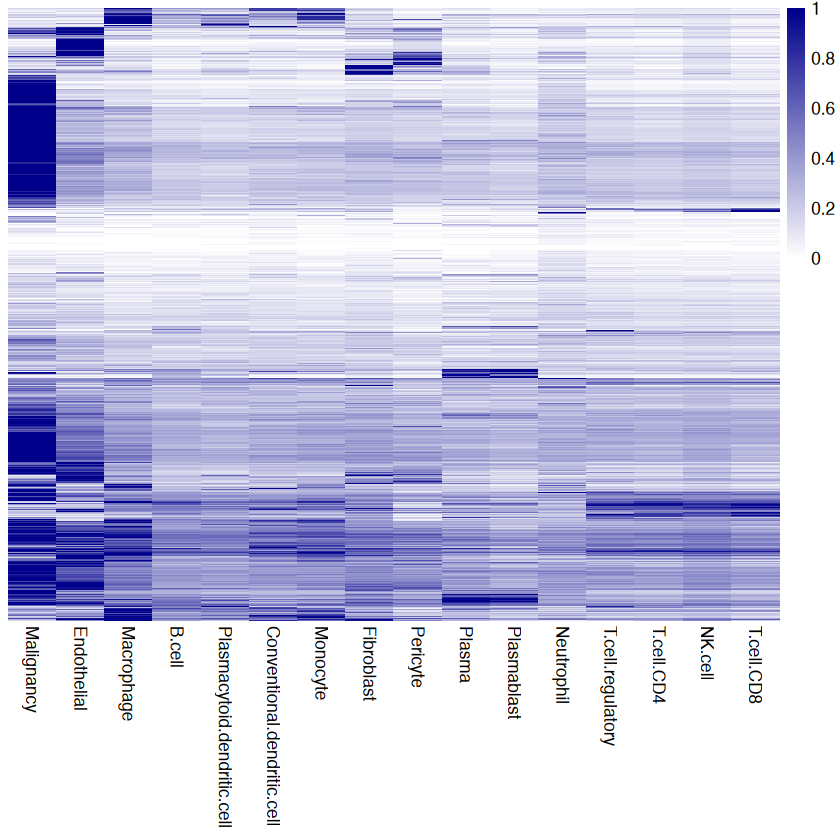

In [18]:
pheatmap::pheatmap(sweep(refprofiles, 1, pmax(apply(refprofiles, 1, max), 0.2), "/"), 
                   col = colorRampPalette(c("white", "darkblue"))(100), 
        treeheight_row = 0,    # hides row dendrogram
        treeheight_col = 0,    # hides column dendrogram
        show_rownames = FALSE  # hides y-axis labels
)

In [19]:
if (method == "semisup") {

  semisup <- insitutype(
    x = counts,
    neg = negmean,
    cohort = if (cohorting) coh else NULL,
    bg = NULL,
    # condensed to save time. n_clusts = 5:15 would be more optimal
    n_clusts = n_clusts,
    reference_profiles = refprofiles,
    update_reference_profiles = FALSE,
    # choosing inadvisably low numbers to speed the vignette; using the defaults
    # in recommended.
    # n_phase1 = 200,
    # n_phase2 = 500,
    # n_phase3 = 2000,
    # n_starts = 1,
    # max_iters = 5
  ) 

}

The following genes in the count data are missing from fixed_profiles and will be omitted from downstream: A1BG,AATK,ACAA2,ACAT2,ACKR1,ADGRE1,ADH1B,ADIRF,AFF2,AGA,AGPAT5,AGRP,AK1,ALDH1L1,ANAPC16,ANGPTL4,ANXA2,AP1S2,AP4E1,APOA1,APOD,AREG,ARNT2,ARX,ASB6,ATF3,ATG4D,ATP1A3,AVPR1B,AXIN2,BIRC3,BOLA2,BST1,C11orf96,C4BPA,C5,C7,C8G,CACNA1A,CADM4,CALML4,CAMTA1,CASP7,CAV2,CCDC80,CCL2,CCL20,CCL21,CCL3,CCNB1,CCND2,CCR10,CD160,CD1C,CD1E,CD22,CD320,CD68,CD83,CD99,CDH11,CDK11A,CDKN2B,CDKN2C,CENPW,CEP164,CFD,CFP,CHIT1,CHL1,CHORDC1,CHPT1,CIB2,CIR1,CLN5,CLU,CMC1,CNIH4,CNTN2,COL18A1,COL1A1,COL3A1,COL4A2,COL4A3,COL5A2,COL8A1,CPAMD8,CPE,CPT2,CRYAB,CSNK2A1,CTNND1,CTSF,CX3CR1,CXCL1,CXCL2,CXCL3,CXCL5,CXCL8,CXCR2,CXCR6,CYCS,CYP1B1,DAAM1,DCN,DCTN5,DDIT3,DERL2,DHX29,DHX38,DISC1,DNAJB1,DTX4,DUSP2,DVL2,EDEM3,EGR1,EIF1AY,ELF4,EMP3,ENDOG,ENY2,EPN1,EREG,ESR2,ESRRA,EZR,F12,FA2H,FAAP20,FAP,FCER1A,FCGR2B,FGF13,FGFBP2,FLRT2,FLT3,FOS,FOSB,FUCA1,FUNDC1,G0S2,GAN,GAR1,GHR,GNG2,GNG7,GPM6A,GPM6B,GPX2,GRIP1,GTF2H5,HADHB,HBB,HBEG

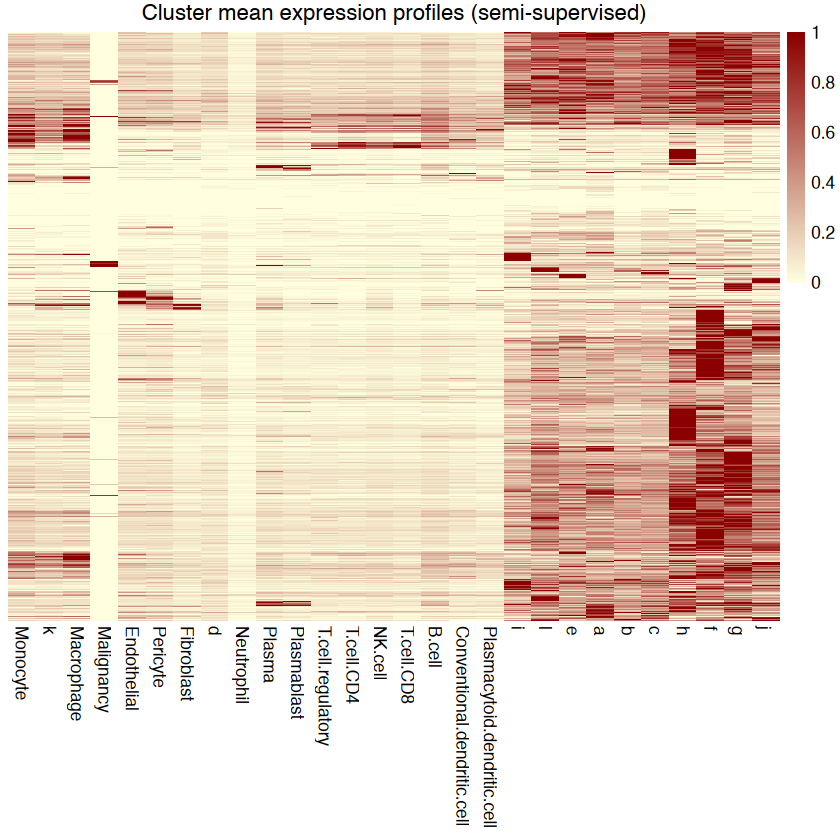

In [20]:
# heatmap(sweep(semisup$profiles, 1, pmax(apply(semisup$profiles, 1, max), .2), "/"), scale = "none",
#         main = "Cluster mean expression profiles (semi-supervised)")

pheatmap::pheatmap(sweep(semisup$profiles, 1, pmax(apply(semisup$profiles, 1, max), .2), "/"), scale = "none", col = colorRampPalette(c("lightyellow", "darkred"))(100),
        main = "Cluster mean expression profiles (semi-supervised)", treeheight_row = 0, treeheight_col = 0, show_rownames = FALSE)

In [21]:
seu$IST_clusters_cohort_original <- seu$IST_clusters_cohort_initial

In [22]:
clusters <- semisup$clust
all(names(clusters) %in% colnames(seu))

# Create a vector with NA for all cells, then fill where available
cluster_metadata <- rep(NA, ncol(seu))
names(cluster_metadata) <- colnames(seu)

# Fill in clusters for matching cells
cluster_metadata[names(clusters)] <- clusters

# Add to Seurat object metadata
if (cohorting) {
    seu$IST_clusters_cohort_initial <- as.factor(cluster_metadata)
    table(seu$IST_clusters_cohort_initial)
    seu$seurat_clusters <- as.factor(cluster_metadata)
    orig_levels <- levels(seu$IST_clusters_cohort_initial)
} else {
    seu$IST_clusters_initial <- as.factor(cluster_metadata)
    table(seu$IST_clusters_initial)
    seu$seurat_clusters <- as.factor(cluster_metadata)
    orig_levels <- levels(seu$IST_clusters_initial)
}

# Identify single letter levels (a single character, not counting ".")
single_letter_levels <- orig_levels[nchar(gsub("\\.", "", orig_levels)) == 1]
not_single_letter_levels <- setdiff(orig_levels, single_letter_levels)

# New order: non-single-letter levels, then the single letters
new_levels <- c(not_single_letter_levels, single_letter_levels)
if (cohorting) {
    seu$IST_clusters_cohort_initial <- factor(seu$IST_clusters_cohort_initial, levels = new_levels)
} else {
    seu$IST_clusters_initial <- factor(seu$IST_clusters_initial, levels = new_levels)
}

[1] TRUE

### Saving data

In [23]:
suffix <- "_initial"
seu_filepath <- file.path(out_dir_seu, paste0("merged_object_", study_name, "_IST_", method, suffix,".RDS"))
saveRDS(seu, seu_filepath)

In [24]:
semisup_filepath <- file.path(full_out_dir, paste0("InsituType_Result_", study_name, "_", method, suffix,".RDS"))
saveRDS(semisup, semisup_filepath)

### (Optional) Loading results data

In [13]:
# Dynamically load the data saved in the previous cells

suffix <- "_initial"
seu_filepath <- file.path(out_dir_seu, paste0("merged_object_", study_name, "_IST_", method, suffix,".RDS"))
semisup_filepath <- file.path(full_out_dir, paste0("InsituType_Result_", study_name, "_", method, suffix,".RDS"))

seu <- readRDS(seu_filepath)
semisup <- readRDS(semisup_filepath)

### Visualizing Initial Results

In [25]:
# Define colors
cluster_cls <- InSituType::colorCellTypes(freqs = table(semisup$clust), palette = "brewers")

cluster_cls["a"] <- "darkred"
cluster_cls["b"] <- "lightpink"
cluster_cls["c"] <- "firebrick"
cluster_cls["d"] <- "salmon"
cluster_cls["e"] <- "indianred1"
cluster_cls["f"] <- "red"
cluster_cls["g"] <- "darkred"
cluster_cls["h"] <- "tomato"
cluster_cls["i"] <- "mistyrose"
cluster_cls["j"] <- "lightcoral"
cluster_cls["k"] <- "deeppink4"
cluster_cls["l"] <- "orangered3"
cluster_cls["m"] <- "rosybrown1"
cluster_cls["n"] <- "brown3"
cluster_cls["o"] <- "palevioletred1"
cluster_cls["p"] <- "red3"
cluster_cls["q"] <- "peachpuff3"
cluster_cls["r"] <- "darkorange3"
cluster_cls["s"] <- "hotpink3"
cluster_cls["t"] <- "indianred4"
cluster_cls["u"] <- "lavenderblush3"
cluster_cls["v"] <- "red4"
cluster_cls["w"] <- "salmon3"
cluster_cls["x"] <- "maroon3"
cluster_cls["y"] <- "snow3"

# T cell subtypes (shades of blue)
cluster_cls["T.cell.CD8"]       <- "navy"
cluster_cls["T.cell.CD4"]       <- "dodgerblue3"
cluster_cls["T.cell.regulatory"]<- "skyblue"

# Plasma / B cell subtypes (shades of orange)
cluster_cls["Plasma"]           <- "darkorange"
cluster_cls["Plasmablast"]      <- "orange"

# Myeloid subtypes (shades of tan/brown)
cluster_cls["Macrophage"]       <- "tan3"
cluster_cls["Monocyte"]         <- "tan2"
cluster_cls["Neutrophil"]       <- "wheat4"

# Tumor / malignancy (shades of red)
cluster_cls["tumor"]            <- "firebrick2"
cluster_cls["Malignancy"]       <- "red3"

# NK cell
cluster_cls["NK.cell"]          <- "deepskyblue1"

# Endothelial
cluster_cls["Endothelial"]      <- "mediumorchid1"

# B cell
cluster_cls["B.cell"]           <- "seagreen3"

# Fibroblast
cluster_cls["Fibroblast"]       <- "gray30"

# Dendritic cells (shades of yellow)
cluster_cls["Conventional.dendritic.cell"] <- "goldenrod2"
cluster_cls["Plasmacytoid.dendritic.cell"] <- "gold"

# Pericyte
cluster_cls["Pericyte"]         <- "deeppink1"

#### (Optional) Running UMAP

In [15]:
Reductions(seu)

[1] "scpearson_pca_nobatch"  "scpearson_umap_nobatch"

In [ ]:
if (run_umap) {
  # Run UMAP
  nfeatures = 3000
  resolution = 0.8
  run_prefix <- "scpearson"
  run_suffix <- "nobatch"
  slot_names = list(
      pca = paste0(run_prefix, "_pca_", run_suffix),
      umap = paste0(run_prefix, "_umap_", run_suffix),
      graph = paste0(run_prefix, "_graph_", run_suffix),
      clusters = paste0(run_prefix, "_clusters_", run_suffix)
  )

  results <- suppressMessages(suppressWarnings(
      apply_scPearsonPCA(seu, nfeatures = nfeatures, slot_names = slot_names, resolution = resolution)
  ))

  seu <- results$seu
  reduction <- slot_names$umap
}

#### Re-clustering at different resolutions

The graph from `apply_scPearsonPCA` is already stored in the Seurat object. Run the cell below to generate new cluster assignments at any resolution without recomputing PCA/UMAP/graph. Each run creates a new metadata column (e.g. `findclusters_res1.2`).

In [ ]:
# Re-run clustering at a different resolution (reuses existing graph — no recomputation)
new_resolution <- 1.2
cluster_col_name <- paste0(slot_names$clusters, "_res", new_resolution)

seu <- Seurat::FindClusters(seu, graph.name = slot_names$graph, resolution = new_resolution)
seu@meta.data[[cluster_col_name]] <- seu@meta.data$seurat_clusters

message(sprintf("Stored %d clusters in column '%s'",
                length(unique(seu@meta.data[[cluster_col_name]])), cluster_col_name))

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 206450
Number of edges: 5359730

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8435
Number of communities: 31
Elapsed time: 52 seconds


Warning message:
“Adding a command log without an assay associated with it”
Stored 31 clusters in column 'scpearson_clusters_nobatch_res1.2'



#### Generate PDF Report

In [27]:
  run_prefix <- "scpearson"
  run_suffix <- "nobatch"
  reduction <- paste0(run_prefix, "_umap_", run_suffix)

In [28]:
## Set cluster_col based on method
if (method == "semisup") {
    if (cohorting) {
        cluster_col <- "IST_clusters_cohort_initial"
    } else {
        cluster_col <- "IST_clusters_initial"
    }
    CT_QC_plot(seu = seu, cluster_col = cluster_col, cluster_pal = cluster_cls, annotation_col = NULL, annotation_pal = NULL, IST_obj = semisup, out_dir = full_out_dir, reduction = reduction)
} else if (method == "louvain") {
    cluster_col <- paste0(slot_names$clusters, "_res", new_resolution)
    cluster_cls <- InSituType::colorCellTypes(freqs = table(seu@meta.data[[cluster_col]]), palette = "brewers")
    CT_QC_plot(seu = seu, cluster_col = cluster_col, cluster_pal = cluster_cls, annotation_col = NULL, annotation_pal = NULL, out_dir = full_out_dir, reduction = reduction)
}

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



[[1]]

[[2]]

[[3]]

[[4]]



Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Saving flightpath_plot to: ./NBClust-Plots/2026-03-16_13-46-56-EDT-flightpath_plot.png



agg_record_553769637 
                   2

In [33]:
characterize_clusters(
  seurat_obj = seu,
  counts = NULL,
  metadata = NULL,
  cluster_col = "IST_clusters_cohort_initial",
  cell_id_col = "cell_ID_new",
  n_top_markers = 20,
  min_cluster_prop = 0.05,
  output_dir = full_out_dir,
  prefix = "IST"
)

Extracting counts and metadata from Seurat object...



Computing markers for 28 clusters...



  |======================================================================| 100%

Selecting top 20 markers per cluster (min_cluster_prop = 0.05)...

Top markers selected: 560 rows across 28 clusters

Computing cluster summary statistics...

  Using PanCK column: Mean.PanCK

  Using CD45 column: Mean.CD45

Saving results to ../outputs/TMA18_CT_Explore/CT/...



In [ ]:
# plot_celltype_highlights(
#   seu = seu,
#   cluster_col = cluster_col,
#   cluster_cls = cluster_cls,
#   out_dir = file.path(full_out_dir, paste0("celltype_highlights_fullspatial", suffix)),
#   background_alpha = 0.07,    # 0.1 = very faded, 0.5 = moderately faded
#   highlight_alpha = 1,
#   ptsize = 0.01,
#   show_legend = FALSE
# )

# # Highlight mode - one celltype at a time in black, others faded
# plot_celltypes_by_region(
#   seu = seu,
#   cluster_col = cluster_col,
#   cluster_cls = cluster_cls,
#   region_col = "region",
#   out_dir = file.path(full_out_dir, paste0("celltype_regions_highlight", suffix)),
#   mode = "highlight",
#   celltypes = NULL,  # All celltypes, or specify c("t_cell", "b_cell")
#   regions_per_page = 4,
#   background_alpha = 0.2,
#   show_legend = FALSE,
#   include_summary = TRUE,
#   ptsize = 0.01
# )

# # All celltypes mode - show all celltypes in normal colors per region
# plot_celltypes_by_region(
#   seu = seu,
#   cluster_col = cluster_col,
#   cluster_cls = cluster_cls,
#   region_col = "region",
#   out_dir = file.path(full_out_dir, paste0("celltype_regions_all", suffix)),
#   mode = "all_celltypes",
#   regions_per_page = 4,
#   include_summary = TRUE,
#   ptsize = 0.01
# )

# # # PNG mode - individual files for each celltype
# # plot_umap_celltype_highlights(
# #   seu = seu,
# #   cluster_col = cluster_col,
# #   cluster_cls = cluster_cls,
# #   out_dir = file.path(full_out_dir, paste0("umap_highlights", suffix)),
# #   reduction = reduction,
# #   celltypes = NULL,  # All celltypes
# #   background_alpha = 0.2,
# #   output_format = "png",
# #   show_legend = TRUE
# # )

# # PDF mode - multi-page comparison document
# plot_umap_celltype_highlights(
#   seu = seu,
#   cluster_col = cluster_col,
#   cluster_cls = cluster_cls,
#   out_dir = file.path(full_out_dir, paste0("umap_highlights", suffix)),
#   reduction = reduction,
#   celltypes = NULL,
#   background_alpha = 0.2,
#   output_format = "pdf",
#   include_summary = TRUE,  # Add summary page at start
#   show_legend = TRUE
# )

### Naming initial clusters

In [147]:
# Configuration

## Whether to (re-)calculate markers or load from disk
calc_markers <- TRUE

## Choose mode: TRUE  = send ALL clusters to the LLM (recommended)
##              FALSE = send only the unknown clusters
all_clusters <- TRUE

## Tissue description for the LLM prompt
mytissuetype <- "FFPE human Breast Cancer (6k plex cosmx data)"

## Prompt construction method: "mean_expression" or "markers_per_cluster"
prompt_method <- "markers_per_cluster"

## Number of top marker genes to keep per cluster (for mean_expression gene selection or markers_per_cluster)
nperclust <- 15

## Unknown cluster IDs (e.g. single-letter labels from semi-supervised clustering)
# unknown_clusters <- unique(markers$cluster[nchar(markers$cluster) == 1 & grepl("^[A-Za-z]$", markers$cluster)])
# unknown_clusters <- c("a", "c", "e", "h", "j", "o", "p")


## Other configuration
suffix <- "_initial"
markers_filepath <- file.path(full_out_dir, paste0("InsituType_Markers_per_clust_", study_name, "_", method, suffix,".RDS"))
anonmap_filepath <- file.path(full_out_dir, paste0("InsituType_AnonMap_", study_name, "_", method, suffix,".csv"))
hm_all_filepath <- file.path(full_out_dir, paste0("InsituType_Heatmap_AllMarkers_Heatmap_", study_name, "_", method, suffix,".pdf"))
hm_unknownclusters_filepath <- file.path(full_out_dir, paste0("InsituType_Heatmap_UnknownClustersMarkers_Heatmap_", study_name, "_", method, suffix,".pdf"))

metadata <- seu@meta.data

## Set cluster_col based on method
if (method == "semisup") {
    if (cohorting) {
        cluster_col <- "IST_clusters_cohort_initial"
    } else {
        cluster_col <- "IST_clusters_initial"
    }
} else if (method == "louvain") {
    cluster_col <- paste0(slot_names$clusters, "_res", new_resolution)
}

cell_id_col <- "cell_ID_new"

## Derive cluster vector from metadata (works for any cluster column)
clust <- setNames(as.character(seu@meta.data[[cluster_col]]), colnames(seu))
clust <- clust[!is.na(clust)]

In [148]:
# Compute or load cluster-wise fold-change metrics
if (calc_markers) {
  markers <- HieraType::clusterwise_foldchange_metrics(
    Matrix::t(counts),
    metadata = metadata,
    cluster_column = cluster_col,
    cellid_column = cell_id_col)

  saveRDS(markers, file = markers_filepath)
} else {
  markers <- readRDS(markers_filepath)
}

  |======================================================================| 100%

In [151]:
# Subset markers based on mode (all vs. unknown clusters)
if (all_clusters) {
  markers_use <- markers
  clust_use   <- clust
} else {
  markers_use <- markers[markers$cluster %in% unknown_clusters, ]
  clust_use   <- clust[clust %in% unknown_clusters]
}

In [152]:
# Derive a concise set of top markers per cluster
# # get a more succinct list of markers: only the top N per cell type:
# # prioritize by fold change, but penalize low-expressers:

markers_use$prioritystat <- (markers_use$cluster_expr + 0.025) / (markers_use$clusterprime_expr + 0.025)
markersshort <- c()

for (name in unique(markers_use$cluster)) {
  inds <- markers_use$cluster == name
  top  <- order(markers_use$prioritystat[inds], decreasing = TRUE)
  top  <- top[seq_len(min(nperclust, sum(inds)))]
  markersshort <- c(markersshort, markers_use$gene[inds][top])
}

markersshort <- unique(markersshort)

message(sprintf("Top markers selected: %d genes across %d clusters",
                length(markersshort), length(unique(markers_use$cluster))))

Top markers selected: 380 genes across 31 clusters



In [153]:
## make a marker heatmap
hm_semisup <- HieraType::marker_heatmap(markers_use)

if (all_clusters) {
    pdf(hm_all_filepath, width = 25, height = 10)
    print(hm_semisup)
    dev.off()
} else {
    pdf(hm_unknownclusters_filepath, width = 25, height = 10)
    print(hm_semisup)
    dev.off()
}

agg_record_804076752 
                   2

In [154]:
# Prepare prompt data based on prompt_method

if (prompt_method == "mean_expression") {
  # Combine data-driven markers with lineage / biology genes
  source("https://raw.githubusercontent.com/Nanostring-Biostats/CosMx-Analysis-Scratch-Space/Main/_code/vignette2/lineage_and_marker_genes.R")
  allusefulmarkers <- intersect(colnames(counts), unique(c(unlist(lineagegenes), markersshort)))

  # Build mean-expression matrix
  meanexpression <- markers_use[, data.table::dcast(.SD, gene ~ cluster, value.var = "cluster_expr")]
  meanexpression <- as.matrix(meanexpression[, -1])
  rownames(meanexpression) <- markers_use[, unique(gene)]
  meanexpression <- meanexpression[allusefulmarkers, ]

  # Keep lineage genes only if reasonably expressed; always keep data-driven markers
  isdenovo <- is.element(rownames(meanexpression), markersshort)
  meanexpression <- meanexpression[isdenovo | apply(meanexpression, 1, max) > 0.2, ]

} else if (prompt_method == "markers_per_cluster") {
  # Build a filtered marker table: top N markers per cluster by prioritystat
  marker_table <- do.call(rbind, lapply(split(markers_use, markers_use$cluster), function(df) {
    df <- df[df$cluster_prop >= 0.05, ]
    df <- df[order(df$prioritystat, decreasing = TRUE), ]
    head(df, nperclust)
  }))
  rownames(marker_table) <- NULL

  # Select and order columns
  keep_cols <- c("cluster", "gene", "cluster_expr", "clusterprime_expr",
                 "fold_change", "cluster_prop", "fold_change_prop")
  marker_table <- as.data.frame(marker_table)[, keep_cols]

  # Round numeric columns to 1 decimal place
  num_cols <- c("cluster_expr", "clusterprime_expr", "fold_change", "cluster_prop", "fold_change_prop")
  marker_table[, num_cols] <- round(marker_table[, num_cols], 1)

  message(sprintf("Marker table for prompt: %d rows across %d clusters",
                  nrow(marker_table), length(unique(marker_table$cluster))))
} else {
  stop("Unknown prompt_method: ", prompt_method, ". Use 'mean_expression' or 'markers_per_cluster'.")
}

Marker table for prompt: 465 rows across 31 clusters



In [155]:
# == Optional: anonymize cluster labels for unbiased LLM classification ========

anonymize_clusters <- FALSE  # set FALSE for the context-informed pass

if (anonymize_clusters) {
  # detect already-anonymized labels
  already_anon <- all(grepl("^c[0-9]+$", unique(markers_use$cluster)))
 
  if (!already_anon) {
    message("Anonymizing cluster labels...")

    cluster_names <- sort(unique(markers_use$cluster))
    anon_map <- setNames(paste0("c", seq_along(cluster_names)), cluster_names)

    # remap everywhere
    markers_use$cluster <- anon_map[markers_use$cluster]
    clust_use           <- anon_map[clust_use]

    if (prompt_method == "mean_expression") {
      colnames(meanexpression) <- anon_map[colnames(meanexpression)]
    } else if (prompt_method == "markers_per_cluster") {
      marker_table$cluster <- anon_map[marker_table$cluster]
    }

    # save mapping for later back-translation
    df <- data.frame(
      anonym_clust = unlist(anon_map),
      semisup_clust = names(anon_map),
      stringsAsFactors = FALSE
    )
    # Export to CSV
    write.csv(df, anonmap_filepath, row.names = FALSE)
    
  } else {
    message("Clusters already anonymized. Skipping anonymization.")
  }
}

In [156]:
# Assemble the LLM prompt

# Dynamic description based on prompt method
profile_desc <- if (prompt_method == "mean_expression") {
  "The second is a table of mean expression levels of various marker genes and lineage-defining genes in each cluster. "
} else if (prompt_method == "markers_per_cluster") {
  "The second is a table of top marker genes per cluster with expression and fold-change statistics. "
}

# the preamble:
prompt_preamble <- paste0(
"Please propose cell type names for the clusters I\'ve found in a CosMx study. This is data from a ", mytissuetype, ". ",
"Below are two tables. The first is each cell type\'s abundance in the dataset. ",
profile_desc,
"It\'s possible that some clusters could be closely-related cell types, or distinct states of the same cell type. Call that out when it\'s apparent. ",
"For each cluster, give me your best guess at its identity, and give me your justification. Let me know when you\'re uncertain. ",
"Then, give me R code defining a named vector called \'cluster_labels\' in which my cluster IDs are the names and the values are your proposed cell types. ",
"Don\'t hallucinate, and triple check your work before replying. ")


prompt_frequencies <- paste0(
"
The cluster frequencies are: ", 
paste0(paste0("cluster ", names(table(clust_use)), ":", table(clust_use)), collapse = ", "))

## give the LLM the cluster profiles:
if (prompt_method == "mean_expression") {
  prompt_profiles <- paste0(
    "And here is a table of each cluster's mean expression of selected data- and biology-derived marker genes: ",
    paste(capture.output(
      write.table(round(meanexpression, 1), sep = ",", row.names = TRUE, col.names = TRUE)
    ), collapse = "\n"))
} else if (prompt_method == "markers_per_cluster") {
  col_description <- paste0(
    "Column descriptions: ",
    "cluster_expr = mean expression in this cluster; ",
    "clusterprime_expr = mean expression in all other clusters; ",
    "fold_change = cluster_expr / clusterprime_expr; ",
    "cluster_prop = proportion of cells in this cluster expressing the gene; ",
    "fold_change_prop = cluster_prop / proportion in all other clusters. "
  )
  prompt_profiles <- paste0(
    "And here is a table of top marker genes per cluster with expression and fold-change statistics. ",
    col_description,
    "Table: \n",
    paste(capture.output(
      write.table(marker_table, sep = ",", row.names = FALSE, col.names = TRUE, quote = FALSE)
    ), collapse = "\n"))
}

full_prompt <- paste0(prompt_preamble, "\n", prompt_frequencies, "\n", prompt_profiles)
message(full_prompt)

# Save prompt
run_id   <- paste0("run_", study_name, "_", cluster_col,
                    "_allclust", all_clusters, "_nperclust", nperclust,
                    "_anon", anonymize_clusters, "_", prompt_method, "_", method, suffix)
run_dir  <- file.path(full_out_dir, paste0("llm_celltyping_runs_", study_name, "_", method, suffix), run_id)
dir.create(run_dir, recursive = TRUE, showWarnings = FALSE)
# save the full prompt
writeLines(full_prompt, file.path(run_dir, "prompt.txt"))

# save old results for rewriting later on:
unnamedclust <- clust_use

if (prompt_method == "mean_expression") {
  unnamedmeanexpression <- meanexpression
  write.csv(
    meanexpression,
    file = file.path(run_dir, "mean_expression.csv"),
    row.names = TRUE
  )
} else if (prompt_method == "markers_per_cluster") {
  write.csv(
    marker_table,
    file = file.path(run_dir, "marker_table.csv"),
    row.names = FALSE
  )
}

Please propose cell type names for the clusters I've found in a CosMx study. This is data from a FFPE human Breast Cancer (6k plex cosmx data). Below are two tables. The first is each cell type's abundance in the dataset. The second is a table of top marker genes per cluster with expression and fold-change statistics. It's possible that some clusters could be closely-related cell types, or distinct states of the same cell type. Call that out when it's apparent. For each cluster, give me your best guess at its identity, and give me your justification. Let me know when you're uncertain. Then, give me R code defining a named vector called 'cluster_labels' in which my cluster IDs are the names and the values are your proposed cell types. Don't hallucinate, and triple check your work before replying. 

The cluster frequencies are: cluster 0:28705, cluster 1:21671, cluster 10:5813, cluster 11:5070, cluster 12:4958, cluster 13:4812, cluster 14:4633, cluster 15:4599, cluster 16:4387, cluster 1

In [ ]:
# paste the LLM's full response here

llm_name <- "claude_incognito_opus4.6"
llm_response <- '
PASTE HERE
'
writeLines(llm_response, file.path(run_dir, paste0(llm_name, "_response.txt")))

# cluster_labels <- "PASTE HERE"

saveRDS(cluster_labels, file.path(run_dir, paste0(llm_name, "_labels.rds")))

In [158]:
# Combine Results
runs_parent_dir <- file.path(full_out_dir, paste0("llm_celltyping_runs_", study_name, "_", method, suffix))
comparison_table <- combine_llm_runs(runs_parent_dir, anonmap_filepath)

out_path <- file.path(runs_parent_dir, paste0("Annotation_Comparison_Table_",study_name,"_",method, suffix,".csv"))
write.csv(
  comparison_table,
  file = out_path,
  row.names = FALSE
)
message(sprintf("Saved comparison table to: %s", out_path))

Found 1 run directories

Collected 31 total label entries across 1 sources

Saved comparison table to: ../outputs/TMA18/CT/llm_celltyping_runs_TMA18_louvain_initial/Annotation_Comparison_Table_TMA18_louvain_initial.csv



In [ ]:
colnames(seu@meta.data)

### Marker Validation

Run Seurat's `FindAllMarkers` (Wilcoxon rank-sum test) as an orthogonal validation of the HieraType fold-change markers. This provides p-values and effect sizes that complement the fold-change-based prioritization.

In [161]:
# Set active identities to the cluster column used for HieraType markers
Idents(seu) <- cluster_col

# Run FindAllMarkers with Wilcoxon rank-sum test
# logfc.threshold = 0.25 : only test genes with >= 0.25 log2FC (filters noise, speeds computation)
# min.pct = 0.1          : gene must be detected in >= 10% of cells in either group (removes very sparse genes)
# only.pos = TRUE        : only return upregulated markers (most useful for cell type identification)
fam_results <- FindAllMarkers(
    seu,
    assay = ASSAY_NAME,
    test.use = "wilcox",
    logfc.threshold = 0.25,
    min.pct = 0.075,
    only.pos = TRUE
)

# Save full results
write.csv(
    fam_results,
    file = file.path(run_dir, "findallmarkers_results.csv"),
    row.names = FALSE
)

message(sprintf("FindAllMarkers: %d markers across %d clusters. Saved to: %s",
                nrow(fam_results), length(unique(fam_results$cluster)),
                file.path(run_dir, "findallmarkers_results.csv")))

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18

Calculating cluster 19

Calculating cluster 20

Calculating cluster 21

Calculating cluster 22

Calculating cluster 23

Calculating cluster 24

Calculating cluster 25

Calculating cluster 26

Calculating cluster 27

Calculating cluster 28

Calculating cluster 29

Calculating cluster 30

FindAllMarkers: 33485 markers across 31 clusters. Saved to: ../outputs/TMA18/CT/llm_celltyping_runs_TMA18_louvain_initial/run_TMA18_scpearson_clusters_nobatch_res1.2_allclustTRUE_nperclust15_anonFALSE_markers_per_cluster_louvain_initial/findallmarkers_results.csv



In [166]:
# Extract top markers per cluster sorted by avg_log2FC
# fam_top_markers <- fam_results %>%
#     group_by(cluster) %>%
#     arrange(desc(avg_log2FC), .by_group = TRUE) %>%
#     slice_head(n = nperclust) %>%
#     ungroup() %>%
#     as.data.frame()

fam_top_markers <- do.call(rbind, lapply(split(fam_results, fam_results$cluster), function(df) {
    # cluster_prop >= 0.05 filter
    df <- df[df$pct.1 >= 0.05, ]
    # FAM-specific: filter for statistical significance
    df <- df[df$p_val_adj < 0.05, ]
    # sort by avg_log2FC descending
    df <- df[order(df$avg_log2FC, decreasing = TRUE), ]
    head(df, nperclust)
}))

# Round numeric columns for readability
num_cols_fam <- c("p_val", "avg_log2FC", "pct.1", "pct.2", "p_val_adj")
num_cols_fam <- intersect(num_cols_fam, colnames(fam_top_markers))
fam_top_markers[, num_cols_fam] <- round(fam_top_markers[, num_cols_fam], 4)

# Save top markers table
write.csv(
    fam_top_markers,
    file = file.path(run_dir, "findallmarkers_top_markers.csv"),
    row.names = FALSE
)

message(sprintf("Top markers: %d genes across %d clusters. Saved to: %s",
                nrow(fam_top_markers), length(unique(fam_top_markers$cluster)),
                file.path(run_dir, "findallmarkers_top_markers.csv")))

Top markers: 465 genes across 31 clusters. Saved to: ../outputs/TMA18/CT/llm_celltyping_runs_TMA18_louvain_initial/run_TMA18_scpearson_clusters_nobatch_res1.2_allclustTRUE_nperclust15_anonFALSE_markers_per_cluster_louvain_initial/findallmarkers_top_markers.csv



In [165]:
# Preview top markers
head(fam_top_markers, n = 30)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
1,0,121.56179,0.030,0.112,0,0,AEBP2
2,0,105.90002,0.070,0.119,0,0,ADRB1
3,0,96.36530,0.049,0.158,0,0,DHX9
4,0,89.11047,0.057,0.124,0,0,MT1G
5,0,72.17407,0.066,0.196,0,0,SURF4
6,0,70.39437,0.037,0.079,0,0,GAS7
7,0,65.94229,0.056,0.160,0,0,MAPK3
8,0,56.01271,0.055,0.186,0,0,PRDX4
9,0,53.85037,0.042,0.157,0,0,FAM3C


#### HieraType vs FindAllMarkers Comparison

Compare the two marker detection methods per cluster:
1. **Jaccard overlap** of top-20 gene lists
2. **Spearman rank correlation** of fold-changes for shared genes
3. **Three-category gene classification** (high confidence / FC only / significant only)

In [168]:
## --- 1. Jaccard Overlap per Cluster ---
# Top 20 genes per cluster from each method
n_compare <- 15

# HieraType top genes per cluster (by prioritystat, filtered by cluster_prop >= 0.05)
ht_top <- markers_use %>%
    filter(cluster_prop >= 0.05) %>%
    group_by(cluster) %>%
    arrange(desc(prioritystat), .by_group = TRUE) %>%
    slice_head(n = n_compare) %>%
    summarise(genes = list(gene), .groups = "drop")

# FindAllMarkers top genes per cluster (by avg_log2FC, filtered by pct.1 >= 0.05)
fam_top <- fam_results %>%
    filter(pct.1 >= 0.05) %>%
    group_by(cluster) %>%
    arrange(desc(avg_log2FC), .by_group = TRUE) %>%
    slice_head(n = n_compare) %>%
    summarise(genes = list(gene), .groups = "drop")

# Compute Jaccard index for each cluster
all_clusters_compare <- union(ht_top$cluster, fam_top$cluster)

jaccard_df <- do.call(rbind, lapply(all_clusters_compare, function(cl) {
    ht_genes <- ht_top$genes[ht_top$cluster == cl][[1]]
    fam_genes <- if (cl %in% fam_top$cluster) fam_top$genes[fam_top$cluster == cl][[1]] else character(0)

    overlap <- intersect(ht_genes, fam_genes)
    union_genes <- union(ht_genes, fam_genes)
    jaccard <- length(overlap) / length(union_genes)

    data.frame(
        cluster = cl,
        jaccard_index = round(jaccard, 3),
        n_overlap = length(overlap),
        n_union = length(union_genes),
        overlapping_genes = paste(sort(overlap), collapse = ", "),
        stringsAsFactors = FALSE
    )
}))

jaccard_df <- jaccard_df[order(jaccard_df$cluster), ]

write.csv(jaccard_df, file = file.path(run_dir, "marker_method_jaccard.csv"), row.names = FALSE)
message(sprintf("Jaccard comparison saved. Mean Jaccard index: %.3f", mean(jaccard_df$jaccard_index)))
jaccard_df

Jaccard comparison saved. Mean Jaccard index: 0.237



,cluster,jaccard_index,n_overlap,n_union,overlapping_genes
,<chr>,<dbl>,<int>,<int>,<chr>
1,0,0.000,0,30,
2,1,0.250,6,24,"COL1A1, COL1A2, COL3A1, FN1, MMP11, POSTN"
3,10,0.364,8,22,"CCND1, CCT2, DHRS2, DHRS4, FGFR1, HPGD, MSMB, RBM4"
4,11,0.200,5,25,"GATA2, HDC, MESP1, SLC18A2, TPSAB1/2"
5,12,0.250,6,24,"AZGP1, CFD, HMGCS2, LRIG1, PGR, SLC40A1"
6,13,0.154,4,26,"ELOVL5, HSP90AB1, LAPTM4B, SERPINA3"
7,14,0.500,10,20,"CTF1, IGHV1-69, IGLC1/2, IGLL1, IGLL5, IGLV1-40, IGLV3-21, IGLV4-69, IGLV6-57, LEF1"
8,15,0.111,3,27,"CA2, HSPB1, SEMA3C"
9,16,0.250,6,24,"ACTA2, CARMN, KRT14, KRT15, PTN, TAGLN"


In [169]:
## --- 2. Spearman Rank Correlation per Cluster ---
# For genes detected by both methods in each cluster, correlate
# HieraType fold_change vs FindAllMarkers avg_log2FC

spearman_df <- do.call(rbind, lapply(all_clusters_compare, function(cl) {
    # HieraType genes and fold changes for this cluster
    ht_cl <- markers_use[markers_use$cluster == cl, c("gene", "fold_change")]
    # FAM genes and avg_log2FC for this cluster
    fam_cl <- fam_results[fam_results$cluster == cl, c("gene", "avg_log2FC")]

    # Inner join on shared genes
    shared <- merge(ht_cl, fam_cl, by = "gene")

    if (nrow(shared) < 3) {
        return(data.frame(cluster = cl, n_shared = nrow(shared),
                          spearman_rho = NA, spearman_pval = NA,
                          stringsAsFactors = FALSE))
    }

    cor_test <- cor.test(shared$fold_change, shared$avg_log2FC, method = "spearman", exact = FALSE)

    data.frame(
        cluster = cl,
        n_shared = nrow(shared),
        spearman_rho = round(cor_test$estimate, 3),
        spearman_pval = signif(cor_test$p.value, 3),
        stringsAsFactors = FALSE
    )
}))

rownames(spearman_df) <- NULL
spearman_df <- spearman_df[order(spearman_df$cluster), ]

write.csv(spearman_df, file = file.path(run_dir, "marker_method_spearman.csv"), row.names = FALSE)
message(sprintf("Spearman comparison saved. Median rho: %.3f", median(spearman_df$spearman_rho, na.rm = TRUE)))
spearman_df

Spearman comparison saved. Median rho: 0.530



,cluster,n_shared,spearman_rho,spearman_pval
,<chr>,<int>,<dbl>,<dbl>
1,0,377,-0.080,1.190000e-01
2,1,283,0.130,2.900000e-02
3,10,2155,0.746,0.000000e+00
4,11,119,0.434,8.370000e-07
5,12,905,0.588,3.780000e-85
6,13,550,0.569,1.600000e-48
7,14,200,0.348,4.610000e-07
8,15,1179,0.519,2.150000e-82
9,16,708,0.530,1.270000e-52


In [170]:
## --- 3. Three-Category Gene Classification per Cluster ---
#
# For each cluster, classify every gene from the union of both methods' top lists:
#   high_confidence : Top FC in HieraType AND significant in FAM (p_val_adj < 0.05)
#                     → Use for cell type annotation
#   fc_only         : Strong HieraType FC, NOT significant in FAM
#                     → Possible marker but uncertain
#   significant_only: FAM significant, weak HieraType FC (not in top list)
#                     → Statistically real but small effect

classification_list <- lapply(all_clusters_compare, function(cl) {
    # Top N HieraType genes for this cluster
    ht_genes <- ht_top$genes[ht_top$cluster == cl][[1]]

    # All FAM significant genes for this cluster (p_val_adj < 0.05)
    fam_cl <- fam_results[fam_results$cluster == cl, ]
    fam_sig_genes <- fam_cl$gene[fam_cl$p_val_adj < 0.05]

    # All FAM top genes for this cluster (for the union)
    fam_top_genes <- if (cl %in% fam_top$cluster) fam_top$genes[fam_top$cluster == cl][[1]] else character(0)

    # Union of genes to classify
    all_genes <- union(ht_genes, fam_top_genes)

    do.call(rbind, lapply(all_genes, function(g) {
        in_ht_top <- g %in% ht_genes
        in_fam_sig <- g %in% fam_sig_genes

        category <- if (in_ht_top && in_fam_sig) {
            "high_confidence"
        } else if (in_ht_top && !in_fam_sig) {
            "fc_only"
        } else {
            "significant_only"
        }

        # Retrieve stats from both methods
        ht_row <- markers_use[markers_use$cluster == cl & markers_use$gene == g, ]
        fam_row <- fam_cl[fam_cl$gene == g, ]

        data.frame(
            cluster = cl,
            gene = g,
            category = category,
            ht_fold_change = if (nrow(ht_row) > 0) round(ht_row$fold_change[1], 2) else NA,
            ht_prioritystat = if (nrow(ht_row) > 0) round(ht_row$prioritystat[1], 2) else NA,
            fam_avg_log2FC = if (nrow(fam_row) > 0) round(fam_row$avg_log2FC[1], 4) else NA,
            fam_p_val_adj = if (nrow(fam_row) > 0) signif(fam_row$p_val_adj[1], 3) else NA,
            stringsAsFactors = FALSE
        )
    }))
})

classification_df <- do.call(rbind, classification_list)
rownames(classification_df) <- NULL

# Sort: cluster, then category priority (high_confidence first), then by HieraType FC
cat_order <- c("high_confidence" = 1, "fc_only" = 2, "significant_only" = 3)
classification_df$cat_rank <- cat_order[classification_df$category]
classification_df <- classification_df[order(classification_df$cluster, classification_df$cat_rank,
                                             -classification_df$ht_fold_change), ]
classification_df$cat_rank <- NULL

write.csv(classification_df, file = file.path(run_dir, "marker_method_classification.csv"), row.names = FALSE)

# Summary counts
cat_summary <- as.data.frame(table(classification_df$category))
colnames(cat_summary) <- c("category", "n_genes")
message(sprintf("Classification saved. Totals: high_confidence=%d, fc_only=%d, significant_only=%d",
                sum(classification_df$category == "high_confidence"),
                sum(classification_df$category == "fc_only"),
                sum(classification_df$category == "significant_only")))

# Show per-cluster summary
table(classification_df$cluster, classification_df$category)

Classification saved. Totals: high_confidence=319, fc_only=146, significant_only=295



    
     fc_only high_confidence significant_only
  0       14               1               15
  1        1              14                9
  10       2              13                7
  11       8               7               10
  12       7               8                9
  13       8               7               11
  14       4              11                5
  15       5              10               12
  16       4              11                9
  17       4              11                8
  18       4              11               11
  19       3              12                9
  2        0              15                6
  20       8               7               10
  21      11               4               13
  22       3              12               10
  23       2              13                9
  24       4              11                7
  25       4              11               13
  26       0              15                6
  27       3              12 

### Refining Clusters / Initial Results

This should be performed iteratively. If the refinement is performed on already previously refined clusters, set already_refined to TRUE.

In [28]:
already_refined <- FALSE

#### (Optional) Load an already refined result

In [29]:
if (already_refined) {
    suffix <- "_refined"
    semisup_refined_filepath <- file.path(full_out_dir, paste0("InsituType_Result_", study_name, "_", method, suffix,".RDS"))
    semisup <- readRDS(semisup_refined_filepath)
}

In [30]:
if (already_refined) {
    unique(seu$IST_clusters_cohort_refined)
} else {
    unique(seu$IST_clusters_cohort_initial)
}

[1] i                           h                          
 [3] d                           p                          
 [5] e                           x                          
 [7] Plasmablast                 Endothelial                
 [9] q                           a                          
[11] g                           T.cell.CD8                 
[13] T.cell.CD4                  Pericyte                   
[15] Conventional.dendritic.cell Plasmacytoid.dendritic.cell
[17] T.cell.regulatory           NK.cell                    
[19] B.cell                      n                          
[21] Monocyte                    o                          
[23] u                           k                          
[25] Neutrophil                  t                          
[27] Fibroblast                  y                          
[29] f                           s                          
[31] Plasma                      b                          
[33] Macrophage                  l                          
[35] r                           v                          
[37] w                           m                          
[39] c                           j                          
[41] Malignancy                 
41 Levels: B.cell Conventional.dendritic.cell Endothelial ... y

In [60]:
semisup_refined <- refineClusters(
      logliks = semisup$logliks, 
      counts = counts,
      neg = negmean, 
    #   merges = c("T.cell.CD4" = "T-cell",
    #              "T.cell.CD8" = "T-cell"),
    #   subcluster = list("d" = 2),      
      to_delete = c("g"))  # delete this cluster and send its cells to their next-best fit    

In [ ]:
clusters <- semisup_refined$clust
all(names(clusters) %in% colnames(seu))

# Create a vector with NA for all cells, then fill where available
cluster_metadata <- rep(NA, ncol(seu))
names(cluster_metadata) <- colnames(seu)

# Fill in clusters for matching cells
cluster_metadata[names(clusters)] <- clusters

# Add to Seurat object metadata
if (cohorting) {
    seu$IST_clusters_cohort_refined <- as.factor(cluster_metadata)
    table(seu$IST_clusters_cohort_refined)
    seu$seurat_clusters <- as.factor(cluster_metadata)
    orig_levels <- levels(seu$IST_clusters_cohort_refined)
} else {
    seu$IST_clusters_refined <- as.factor(cluster_metadata)
    table(seu$IST_clusters_refined)
    seu$seurat_clusters <- as.factor(cluster_metadata)
    orig_levels <- levels(seu$IST_clusters_refined)
}

# Identify single letter levels (a single character, not counting ".")
single_letter_levels <- orig_levels[nchar(gsub("\\.", "", orig_levels)) == 1]
not_single_letter_levels <- setdiff(orig_levels, single_letter_levels)

# New order: non-single-letter levels, then the single letters
new_levels <- c(not_single_letter_levels, single_letter_levels)
if (cohorting) {
    seu$IST_clusters_cohort_refined <- factor(seu$IST_clusters_cohort_refined, levels = new_levels)
} else {
    seu$IST_clusters_refined <- factor(seu$IST_clusters_refined, levels = new_levels)
}

In [ ]:
suffix <- "_refined"

semisup_refined_filepath <- file.path(full_out_dir, paste0("InsituType_Result_", study_name, "_", method, suffix,".RDS"))
saveRDS(semisup_refined, semisup_refined_filepath)

seu_filepath <- file.path(out_dir_seu, paste0("merged_object_", study_name, "_IST_", method, suffix,".RDS"))
saveRDS(seu, seu_filepath)

In [ ]:
if (cohorting) {
    cluster_col <- "IST_clusters_cohort_refined"
} else {
    cluster_col <- "IST_clusters_refined"
}

CT_QC_plot(seu = seu, cluster_col = cluster_col, cluster_pal = cluster_cls, annotation_col = NULL, annotation_pal = NULL, IST_obj = semisup_refined, out_dir = full_out_dir, reduction = reduction)

In [ ]:
plot_celltype_highlights(
  seu = seu,
  cluster_col = cluster_col,
  cluster_cls = cluster_cls,
  out_dir = file.path(full_out_dir, paste0("celltype_highlights_fullspatial", suffix)),
  background_alpha = 0.07,    # 0.1 = very faded, 0.5 = moderately faded
  highlight_alpha = 1,
  ptsize = 0.01,
  show_legend = FALSE
)

# Highlight mode - one celltype at a time in black, others faded
plot_celltypes_by_region(
  seu = seu,
  cluster_col = cluster_col,
  cluster_cls = cluster_cls,
  region_col = "region",
  out_dir = file.path(full_out_dir, paste0("celltype_regions_highlight", suffix)),
  mode = "highlight",
  celltypes = NULL,  # All celltypes, or specify c("t_cell", "b_cell")
  regions_per_page = 4,
  background_alpha = 0.2,
  show_legend = FALSE,
  include_summary = TRUE,
  ptsize = 0.01
)

# All celltypes mode - show all celltypes in normal colors per region
plot_celltypes_by_region(
  seu = seu,
  cluster_col = cluster_col,
  cluster_cls = cluster_cls,
  region_col = "region",
  out_dir = file.path(full_out_dir, paste0("celltype_regions_all", suffix)),
  mode = "all_celltypes",
  regions_per_page = 4,
  include_summary = TRUE,
  ptsize = 0.01
)

# # PNG mode - individual files for each celltype
# plot_umap_celltype_highlights(
#   seu = seu,
#   cluster_col = cluster_col,
#   cluster_cls = cluster_cls,
#   out_dir = file.path(full_out_dir, paste0("umap_highlights", suffix)),
#   reduction = reduction,
#   celltypes = NULL,  # All celltypes
#   background_alpha = 0.2,
#   output_format = "png",
#   show_legend = TRUE
# )

# PDF mode - multi-page comparison document
plot_umap_celltype_highlights(
  seu = seu,
  cluster_col = cluster_col,
  cluster_cls = cluster_cls,
  out_dir = file.path(full_out_dir, paste0("umap_highlights", suffix)),
  reduction = reduction,
  celltypes = NULL,
  background_alpha = 0.2,
  output_format = "pdf",
  include_summary = TRUE,  # Add summary page at start
  show_legend = TRUE
)

# Final Annotations

In [172]:
# Print all celltypes
cluster_col <- "scpearson_clusters_nobatch_res1.2"

unique(seu@meta.data[[cluster_col]])
length(unique(seu@meta.data[[cluster_col]]))

[1] 28 1  0  12 24 4  16 13 3  2  5  14 17 25 9  30 11 6  10 20 7  15 19 23 27
[26] 21 8  29 22 26 18
31 Levels: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 30

[1] 31

In [173]:
cluster_to_celltype <- c(
  "0"  = "low_quality_subcluster",
  "1"  = "caf",
  "2"  = "macrophage",
  "3"  = "t_nk_cell",
  "4"  = "endothelial_perivascular",
  "5"  = "tumor_1_LE",
  "6"  = "myoepithelial_proliferating",
  "7"  = "tumor_2_LE",
  "8"  = "tumor_3_LE",
  "9"  = "tumor_4_LE",
  "10" = "tumor_5_LE",
  "11" = "tumor_6_LE",
  "12" = "tumor_7_LE",
  "13" = "tumor_8_LE",
  "14" = "plasma",
  "15" = "tumor_9_LE",
  "16" = "basal_myoepithelial",
  "17" = "plasma",
  "18" = "tumor_10_LE",
  "19" = "tumor_11_HER2+",
  "20" = "tumor_12_LE",
  "21" = "tumor_13_LE",
  "22" = "epithelial_stressed_basal_like",
  "23" = "tumor_14_LE",
  "24" = "tumor_15_LE",
  "25" = "b_cell",
  "26" = "tumor_16_HER2+",
  "27" = "tumor_17_HER2+",
  "28" = "plasma",
  "29" = "tumor_18_HER2+",
  "30" = "osteoclast_like_myeloid_giant"
)

length(cluster_to_celltype)


[1] 31

In [ ]:
# # Mapping clusters to celltypes
# cluster_to_celltype <- c(
#   a = "tam_inflammatory",
#   b = "tumor_1",
#   c = "tam_resident_like",
#   d = "tumor_2",
#   e = "caf_adipogenic",
#   f = "tumor_3",
#   g = "tumor_4",
#   h = "plasma",
#   i = "tumor_5",
#   j = "vsmc_like",
#   k = "tumor_6",
#   l = "tumor_7",
#   m = "tumor_8",
#   n = "tumor_9",
#   o = "t_cell_cytotoxic",
#   p = "caf",
#   q = "tumor_10",
#   r = "tumor_11",
#   s = "tumor_12",
#   t = "tumor_13",
#   u = "tumor_14",
#   v = "tumor_15",
#   w = "tumor_16",
#   x = "tumor_17",
#   y = "tumor_18",
#   t.cell.cd8 = "t_cell_cd8",
#   t.cell.cd4 = "t_cell_cd4",
#   t.cell.regulatory = "t_cell_regulatory",
#   nk.cell = "nk_cell",
#   b.cell = "b_cell",
#   plasmablast = "plasma",
#   plasma = "plasma",
#   monocyte = "monocyte",
#   macrophage = "macrophage",
#   neutrophil = "neutrophil",
#   conventional.dendritic.cell = "dendritic_cell",
#   plasmacytoid.dendritic.cell = "dendritic_cell",
#   fibroblast = "fibroblast",
#   pericyte = "pericyte",
#   endothelial = "endothelial",
#   malignancy = "malignancy"
# )

# length(cluster_to_celltype)

In [174]:
# create new metadata column via named lookup
seu@meta.data$final_annotation <-
  unname(cluster_to_celltype[seu@meta.data[[cluster_col]]])

table(seu@meta.data$final_annotation, useNA = "ifany")


                        b_cell            basal_myoepithelial 
                          2023                           4387 
                           caf       endothelial_perivascular 
                         21671                          11666 
epithelial_stressed_basal_like         low_quality_subcluster 
                          3485                          28705 
                    macrophage    myoepithelial_proliferating 
                         20043                           6484 
 osteoclast_like_myeloid_giant                         plasma 
                          1242                          10470 
                     t_nk_cell                     tumor_1_LE 
                         16753                           8787 
                   tumor_10_LE                 tumor_11_HER2+ 
                          4185                           3873 
                   tumor_12_LE                    tumor_13_LE 
                          3730                        

In [ ]:
# # Mapping clusters to celltypes
# cluster_to_celltype_broad <- c(
#   a = "tam",
#   b = "tumor",
#   c = "tam",
#   d = "tumor",
#   e = "caf_adipogenic",
#   f = "tumor",
#   g = "tumor",
#   h = "plasma",
#   i = "tumor",
#   j = "vsmc_like",
#   k = "tumor",
#   l = "tumor",
#   m = "tumor",
#   n = "tumor",
#   o = "t_cell",
#   p = "caf",
#   q = "tumor",
#   r = "tumor",
#   s = "tumor",
#   t = "tumor",
#   u = "tumor",
#   v = "tumor",
#   w = "tumor",
#   x = "tumor",
#   y = "tumor",
#   t.cell.cd8 = "t_cell",
#   t.cell.cd4 = "t_cell",
#   t.cell.regulatory = "t_cell",
#   nk.cell = "nk_cell",
#   b.cell = "b_cell",
#   plasmablast = "plasma",
#   plasma = "plasma",
#   monocyte = "monocyte",
#   macrophage = "macrophage",
#   neutrophil = "neutrophil",
#   conventional.dendritic.cell = "dendritic_cell",
#   plasmacytoid.dendritic.cell = "dendritic_cell",
#   fibroblast = "fibroblast",
#   pericyte = "pericyte",
#   endothelial = "endothelial",
#   malignancy = "tumor"
# )

# length(cluster_to_celltype_broad)

[1] 41

In [142]:
# create new metadata column via named lookup
seu@meta.data$broad_annotation <-
  unname(cluster_to_celltype_broad[seu@meta.data[[cluster_col]]])

table(seu@meta.data$broad_annotation, useNA = "ifany")


        b_cell            caf caf_adipogenic dendritic_cell    endothelial 
          2870            705            105           3335            975 
    fibroblast     macrophage       monocyte     neutrophil        nk_cell 
          7334           1942            369           7888           9629 
      pericyte         plasma         t_cell            tam          tumor 
          9958          31375          17190           1356         110361 
     vsmc_like 
           397 

In [143]:
suffix <- "_final"

seu_filepath <- file.path(out_dir_seu, paste0("merged_object_", study_name, "_IST_", method, suffix,".RDS"))
saveRDS(seu, seu_filepath)

## Streamlined Final Annotations

In [175]:
# --- 1. Define cluster column and annotation map ---

## Set cluster_col based on method
if (method == "semisup") {
    if (cohorting) {
        cluster_col <- "IST_clusters_cohort_initial"
    } else {
        cluster_col <- "IST_clusters_initial"
    }
} else if (method == "louvain") {
    cluster_col <- paste0(slot_names$clusters, "_res", new_resolution)
}

# Define cluster-to-celltype mapping
cluster_to_celltype <- c(
  "0"  = "low_quality_subcluster",
  "1"  = "caf",
  "2"  = "macrophage",
  "3"  = "t_nk_cell",
  "4"  = "endothelial_perivascular",
  "5"  = "tumor_1_LE",
  "6"  = "myoepithelial_proliferating",
  "7"  = "tumor_2_LE",
  "8"  = "tumor_3_LE",
  "9"  = "tumor_4_LE",
  "10" = "tumor_5_LE",
  "11" = "tumor_6_LE",
  "12" = "tumor_7_LE",
  "13" = "tumor_8_LE",
  "14" = "plasma",
  "15" = "tumor_9_LE",
  "16" = "basal_myoepithelial",
  "17" = "plasma",
  "18" = "tumor_10_LE",
  "19" = "tumor_11_HER2+",
  "20" = "tumor_12_LE",
  "21" = "tumor_13_LE",
  "22" = "epithelial_stressed_basal_like",
  "23" = "tumor_14_LE",
  "24" = "tumor_15_LE",
  "25" = "b_cell",
  "26" = "tumor_16_HER2+",
  "27" = "tumor_17_HER2+",
  "28" = "plasma",
  "29" = "tumor_18_HER2+",
  "30" = "osteoclast_like_myeloid_giant"
)

message(sprintf("Using cluster column: %s (%d clusters mapped)", cluster_col, length(cluster_to_celltype)))

Using cluster column: scpearson_clusters_nobatch_res1.2 (31 clusters mapped)



In [177]:
# --- 2. Save annotation map to disk ---

annot_dir <- file.path(full_out_dir, "annotations", paste0("final_annotations_", cluster_col, "_", study_name, "_", method))
dir.create(annot_dir, recursive = TRUE, showWarnings = FALSE)

# Save as CSV (human-readable)
annot_csv <- data.frame(
    cluster = names(cluster_to_celltype),
    celltype = unname(cluster_to_celltype),
    stringsAsFactors = FALSE
)
write.csv(annot_csv, file.path(annot_dir, "cluster_to_celltype.csv"), row.names = FALSE)

# Save as RDS (preserves R types for easy re-import)
saveRDS(cluster_to_celltype, file.path(annot_dir, "cluster_to_celltype.rds"))

message(sprintf("Annotation map saved to: %s", annot_dir))

Annotation map saved to: ../outputs/TMA18/CT/annotations/final_annotations_scpearson_clusters_nobatch_res1.2_TMA18_louvain



In [178]:
# --- 3. Apply final_annotation to Seurat object ---

seu$final_annotation <- unname(cluster_to_celltype[as.character(seu@meta.data[[cluster_col]])])

table(seu$final_annotation, useNA = "ifany")


                        b_cell            basal_myoepithelial 
                          2023                           4387 
                           caf       endothelial_perivascular 
                         21671                          11666 
epithelial_stressed_basal_like         low_quality_subcluster 
                          3485                          28705 
                    macrophage    myoepithelial_proliferating 
                         20043                           6484 
 osteoclast_like_myeloid_giant                         plasma 
                          1242                          10470 
                     t_nk_cell                     tumor_1_LE 
                         16753                           8787 
                   tumor_10_LE                 tumor_11_HER2+ 
                          4185                           3873 
                   tumor_12_LE                    tumor_13_LE 
                          3730                        

### (Optional) Integrate Subclustering

Load a subclustered Seurat object and replace the parent cluster label in `final_annotation` with the more granular subcluster labels.

In [179]:
# --- 4. Import subclustering and merge into final_annotation ---

integrate_subcluster <- TRUE  # set TRUE to run subclustering integration

if (integrate_subcluster) {

    # Configuration (update these for your subclustering)
    subcluster_seu_path <- "../outputs/TMA18/seurat_objects/subcluster_scpearson_clusters_nobatch_res1.2_0_TMA18_res0.8.RDS"
    subcluster_col      <- "subclust_0_clusters_res0.8"        # column name in the subcluster object
    parent_cluster_label <- "low_quality_subcluster"               # label in final_annotation to replace

    # (Optional) Rename raw subcluster IDs to meaningful annotations
    # Set to NULL to keep raw subcluster IDs as-is
    subcluster_to_celltype <- c(
      "0" = NA,                # filter out (unknown)
      "1" = "caf",
      "2" = "tumor_19_LE",
      "3" = NA,                # filter out (looks like T/NK cell)
      "4" = "myeloid",
      "5" = "plasma",
      "6" = NA,                # filter out (looks like tumor)
      "7" = "tumor_20_HER2+",
      "8" = "adipocyte"
    )

    # Load subcluster object and extract labels
    seu_sub <- readRDS(subcluster_seu_path)
    sub_labels <- setNames(
        as.character(seu_sub@meta.data[[subcluster_col]]),
        colnames(seu_sub)
    )
    rm(seu_sub)

    # Only update cells that: exist in main object, have the parent label, and have non-NA subcluster
    cells_to_update <- intersect(names(sub_labels), colnames(seu))
    sub_labels <- sub_labels[cells_to_update]
    sub_labels <- sub_labels[!is.na(sub_labels)]

    is_parent <- seu$final_annotation[names(sub_labels)] == parent_cluster_label
    is_parent[is.na(is_parent)] <- FALSE
    sub_labels <- sub_labels[is_parent]

    # Rename subcluster IDs if mapping is provided
    if (!is.null(subcluster_to_celltype)) {
        sub_labels_renamed <- unname(subcluster_to_celltype[sub_labels])
        names(sub_labels_renamed) <- names(sub_labels)

        # Cells mapped to NA keep their parent label (effectively filtered out / unchanged)
        na_cells <- is.na(sub_labels_renamed)
        message(sprintf("Subclusters mapped to NA (keeping as '%s'): %d cells",
                        parent_cluster_label, sum(na_cells)))
        sub_labels_renamed <- sub_labels_renamed[!na_cells]
        sub_labels <- sub_labels_renamed
    }

    message(sprintf("Replacing '%s' in %d cells with subclusters: %s",
                    parent_cluster_label, length(sub_labels),
                    paste(sort(unique(sub_labels)), collapse = ", ")))

    # Apply subcluster labels
    seu$final_annotation[names(sub_labels)] <- sub_labels

    # Save subclustering info to annotations folder
    subcluster_info <- data.frame(
        parent_cluster = parent_cluster_label,
        subcluster_col = subcluster_col,
        subclusters = paste(sort(unique(sub_labels)), collapse = ", "),
        n_cells = length(sub_labels),
        stringsAsFactors = FALSE
    )
    if (!is.null(subcluster_to_celltype)) {
        subcluster_map_csv <- data.frame(
            subcluster_id = names(subcluster_to_celltype),
            annotation = unname(subcluster_to_celltype),
            stringsAsFactors = FALSE
        )
        write.csv(subcluster_map_csv, file.path(annot_dir, "subcluster_to_celltype.csv"), row.names = FALSE)
    }
    write.csv(subcluster_info, file.path(annot_dir, "subcluster_info.csv"), row.names = FALSE)
    message(sprintf("Subcluster info saved to: %s", annot_dir))

    table(seu$final_annotation, useNA = "ifany")
}

Subclusters mapped to NA (keeping as 'low_quality_subcluster'): 16746 cells

Replacing 'low_quality_subcluster' in 11959 cells with subclusters: adipocyte, caf, myeloid, plasma, tumor_19_LE, tumor_20_HER2+

Subcluster info saved to: ../outputs/TMA18/CT/annotations/final_annotations_scpearson_clusters_nobatch_res1.2_TMA18_louvain




                     adipocyte                         b_cell 
                           336                           2023 
           basal_myoepithelial                            caf 
                          4387                          25735 
      endothelial_perivascular epithelial_stressed_basal_like 
                         11666                           3485 
        low_quality_subcluster                     macrophage 
                         16746                          20043 
                       myeloid    myoepithelial_proliferating 
                          2647                           6484 
 osteoclast_like_myeloid_giant                         plasma 
                          1242                          11330 
                     t_nk_cell                     tumor_1_LE 
                         16753                           8787 
                   tumor_10_LE                 tumor_11_HER2+ 
                          4185                        

### Broad Annotation

In [ ]:
# --- 5. Create broad_annotation column ---

# Map each final_annotation to a broad category
celltype_to_broad <- c(
  "low_quality_subcluster"         = "low_quality",
  "caf"                            = "caf",
  "macrophage"                     = "myeloid",
  "t_nk_cell"                      = "t_nk_cell",
  "endothelial_perivascular"       = "endothelial_perivascular",
  "tumor_1_LE"                     = "tumor",
  "myoepithelial_proliferating"    = "myoepithelial",
  "tumor_2_LE"                     = "tumor",
  "tumor_3_LE"                     = "tumor",
  "tumor_4_LE"                     = "tumor",
  "tumor_5_LE"                     = "tumor",
  "tumor_6_LE"                     = "tumor",
  "tumor_7_LE"                     = "tumor",
  "tumor_8_LE"                     = "tumor",
  "plasma"                         = "plasma",
  "tumor_9_LE"                     = "tumor",
  "basal_myoepithelial"            = "myoepithelial",
  "tumor_10_LE"                    = "tumor",
  "tumor_11_HER2+"                 = "tumor",
  "tumor_12_LE"                    = "tumor",
  "tumor_13_LE"                    = "tumor",
  "epithelial_stressed_basal_like" = "epithelial",
  "tumor_14_LE"                    = "tumor",
  "tumor_15_LE"                    = "tumor",
  "b_cell"                         = "b_cell",
  "tumor_16_HER2+"                 = "tumor",
  "tumor_17_HER2+"                 = "tumor",
  "tumor_18_HER2+"                 = "tumor",
  "osteoclast_like_myeloid_giant"  = "myeloid",
  # Subcluster-derived labels
  "tumor_19_LE"                    = "tumor",
  "tumor_20_HER2+"                 = "tumor",
  "myeloid"                        = "myeloid",
  "adipocyte"                      = "adipocyte"
)

# Apply broad annotation
seu$broad_annotation <- unname(celltype_to_broad[seu$final_annotation])

# Save broad annotation map to annotations folder
broad_csv <- data.frame(
    final_annotation = names(celltype_to_broad),
    broad_annotation = unname(celltype_to_broad),
    stringsAsFactors = FALSE
)
write.csv(broad_csv, file.path(annot_dir, "celltype_to_broad.csv"), row.names = FALSE)
message(sprintf("Broad annotation map saved to: %s", file.path(annot_dir, "celltype_to_broad.csv")))

table(seu$broad_annotation, useNA = "ifany")

Broad annotation map saved to: ../outputs/TMA18/CT/annotations/final_annotations_scpearson_clusters_nobatch_res1.2_TMA18_louvain/celltype_to_broad.csv




               adipocyte                   b_cell                      caf 
                     336                     2023                    25735 
endothelial_perivascular               epithelial              low_quality 
                   11666                     3485                    16746 
                 myeloid            myoepithelial                   plasma 
                   23932                    10871                    11330 
               t_nk_cell                    tumor 
                   16753                    83573 

In [183]:
# --- Filter out celltypes ---

filter_col   <- "broad_annotation"
filter_values <- c("low_quality")

n_before <- ncol(seu)
seu <- subset(seu, cells = colnames(seu)[!seu@meta.data[[filter_col]] %in% filter_values])
n_after <- ncol(seu)

message(sprintf("Filtered out %d cells where %s in {%s}. Remaining: %d",
                n_before - n_after, filter_col, paste(filter_values, collapse = ", "), n_after))

Filtered out 16746 cells where broad_annotation in {low_quality}. Remaining: 189704



In [184]:
# --- 6. Save final Seurat object ---
suffix <- "_final"
seu_filepath <- file.path(out_dir_seu, paste0("annotated_object_", study_name, "_", method, suffix, ".RDS"))
saveRDS(seu, seu_filepath)
message(sprintf("Final Seurat object saved to: %s", seu_filepath))

Final Seurat object saved to: ../outputs/TMA18/seurat_objects/annotated_object_TMA18_louvain_final.RDS



# TESTING